# 20. Strategy Optimization and Final System

## Objective
Improve profitability and risk-adjusted performance by optimizing:

1. Regime filtering (MEDIUM only)
2. Top-K confidence signal selection
3. Position sizing and daily weight normalization
4. Transaction-cost-aware backtesting

Primary goal: maximize Sharpe ratio, not raw prediction accuracy.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 220)

TOP_K_PCT = 0.05
TXN_COST = 0.001  # 0.1% per trade (weighted)
ANNUALIZATION_DAYS = 252

logger = logging.getLogger('strategy_optimization')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

## STEP 1: Load Data

In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to resolve project root containing ml_pipeline and CLAUDE.md')


def resolve_paths(root: Path) -> Dict[str, Path]:
    base = root / 'ml_pipeline'
    return {
        'decision_dataset': base / 'Market_Data' / 'final' / 'final_decision_dataset.parquet',
        'processed_dataset': base / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet',
        'strategy_output': base / 'Market_Data' / 'final' / 'final_strategy_results.parquet',
    }


ROOT = resolve_project_root()
PATHS = resolve_paths(ROOT)

assert PATHS['decision_dataset'].exists(), f"Missing file: {PATHS['decision_dataset']}"
assert PATHS['processed_dataset'].exists(), f"Missing file: {PATHS['processed_dataset']}"

decision_df = pd.read_parquet(PATHS['decision_dataset']).copy()
decision_df['Date'] = pd.to_datetime(decision_df['Date'])

market_df = pd.read_parquet(
    PATHS['processed_dataset'],
    columns=['Ticker', 'Date', 'Close', 'volatility_regime_label'],
).copy()
market_df['Date'] = pd.to_datetime(market_df['Date'])
market_df = market_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

required_cols = {'Ticker', 'Date', 'Regime', 'Probability', 'Decision'}
assert required_cols.issubset(decision_df.columns), f"Decision dataset missing: {required_cols - set(decision_df.columns)}"

logger.info('Decision rows: %s', f'{len(decision_df):,}')
logger.info('Market rows: %s', f'{len(market_df):,}')
display(decision_df.head())

[INFO] Decision rows: 21,888
[INFO] Market rows: 63,541


,Ticker,Date,Regime,Probability,Decision,Selected,Decision_Pred,Prediction,Confidence,Model Used,target
0,ABB,2025-01-29,HIGH,0.494498,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
1,ABB,2025-01-30,HIGH,0.502987,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,1
2,ABB,2025-01-31,HIGH,0.492936,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
3,ABB,2025-02-01,HIGH,0.506073,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
4,ABB,2025-02-03,HIGH,0.496291,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,1


## Build Return Frame for Backtesting

In [3]:
market_df['Close_t1'] = market_df.groupby('Ticker', sort=False)['Close'].shift(-1)
market_df['daily_return'] = (market_df['Close_t1'] - market_df['Close']) / market_df['Close']
returns_df = market_df[['Ticker', 'Date', 'daily_return', 'volatility_regime_label']].dropna(subset=['daily_return']).reset_index(drop=True)

bt_df = decision_df.merge(returns_df, on=['Ticker', 'Date'], how='left')
missing = int(bt_df['daily_return'].isna().sum())
if missing > 0:
    logger.info('Dropping %d rows without t+1 close.', missing)
    bt_df = bt_df.dropna(subset=['daily_return']).reset_index(drop=True)

bt_df = bt_df.rename(columns={'volatility_regime_label': 'volatility_regime_label_source'})
bt_df['Regime'] = bt_df['Regime'].astype(str).str.upper()
bt_df['volatility_regime_label'] = bt_df['volatility_regime_label_source'].astype(str).str.upper()

regime_match = (bt_df['Regime'] == bt_df['volatility_regime_label']).mean()
logger.info('Regime alignment rate: %.2f%%', 100 * regime_match)

assert bt_df['daily_return'].isna().sum() == 0
display(bt_df[['Ticker', 'Date', 'Regime', 'Decision', 'Probability', 'daily_return']].head())

[INFO] Dropping 96 rows without t+1 close.
[INFO] Regime alignment rate: 100.00%


,Ticker,Date,Regime,Decision,Probability,daily_return
0,ABB,2025-01-29,HIGH,NO TRADE,0.494498,-0.064066
1,ABB,2025-01-30,HIGH,NO TRADE,0.502987,0.027153
2,ABB,2025-01-31,HIGH,NO TRADE,0.492936,-0.063859
3,ABB,2025-02-01,HIGH,NO TRADE,0.506073,-0.054941
4,ABB,2025-02-03,HIGH,NO TRADE,0.496291,0.083158


## STEP 2 / 3 / 4 / 5 / 6: Strategy Construction

Strategies:
1. Original strategy
2. MEDIUM-only
3. Top-K only
4. Combined (MEDIUM + Top-K)
5. Buy & Hold benchmark

Sizing:
\[ raw\_size = |p - 0.5| * 2 \]
Daily normalized weight per strategy among active positions.

Cost:
\[ net\_return = gross\_return - 0.1\% * |weight| \]

In [4]:
def infer_side_from_decision(decision_series: pd.Series, prob_series: pd.Series) -> np.ndarray:
    d = decision_series.astype(str).str.upper()
    # Fallback on probability direction for non-explicit labels
    return np.where(d == 'BUY', 1, np.where(d == 'SELL', -1, np.where(prob_series >= 0.5, 1, -1)))


def mark_top_k_per_day(df_in: pd.DataFrame, pct: float = 0.05) -> pd.Series:
    conf = (df_in['Probability'] - 0.5).abs()
    tmp = df_in[['Date']].copy()
    tmp['confidence_abs'] = conf.values

    def _pick(g: pd.DataFrame) -> pd.Series:
        k = max(1, int(np.ceil(len(g) * pct)))
        idx = g['confidence_abs'].nlargest(k).index
        out = pd.Series(False, index=g.index)
        out.loc[idx] = True
        return out

    return tmp.groupby('Date', group_keys=False).apply(_pick)


def apply_strategy_filters(df_in: pd.DataFrame, strategy_name: str) -> pd.DataFrame:
    out = df_in.copy()
    d = out['Decision'].astype(str).str.upper()
    base_trade = d.isin(['BUY', 'SELL'])
    medium_only = out['volatility_regime_label'] == 'MEDIUM'
    topk = mark_top_k_per_day(out, pct=TOP_K_PCT)

    if strategy_name == 'Original strategy':
        trade_mask = base_trade
    elif strategy_name == 'MEDIUM-only':
        trade_mask = base_trade & medium_only
    elif strategy_name == 'Top-K only':
        trade_mask = base_trade & topk
    elif strategy_name == 'Combined (BEST candidate)':
        trade_mask = base_trade & medium_only & topk
    else:
        raise ValueError(f'Unknown strategy: {strategy_name}')

    out['trade_mask'] = trade_mask
    out['side'] = infer_side_from_decision(out['Decision'], out['Probability'])
    out['raw_size'] = (out['Probability'] - 0.5).abs() * 2.0
    out['raw_size'] = out['raw_size'].clip(lower=0.0)
    out.loc[~out['trade_mask'], 'raw_size'] = 0.0

    out['daily_size_sum'] = out.groupby('Date')['raw_size'].transform('sum')
    out['weight'] = np.where(out['daily_size_sum'] > 0, out['raw_size'] / out['daily_size_sum'], 0.0)
    out['weight'] = out['weight'] * out['side']

    out['gross_return'] = out['weight'] * out['daily_return']
    out['txn_cost'] = TXN_COST * out['weight'].abs()
    out['net_return'] = out['gross_return'] - out['txn_cost']
    return out


def apply_buy_hold(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()
    out['trade_mask'] = True
    out['side'] = 1
    # Equal-weight long basket each day
    out['weight'] = 1.0 / out.groupby('Date')['Ticker'].transform('count')
    out['gross_return'] = out['weight'] * out['daily_return']
    out['txn_cost'] = 0.0
    out['net_return'] = out['gross_return']
    out['raw_size'] = out['weight']
    out['daily_size_sum'] = 1.0
    return out

## STEP 7: Backtest Metrics

In [5]:
def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = (equity / running_max) - 1.0
    return float(dd.min())


def sharpe_ratio(daily_returns: pd.Series, annualization: int = 252) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0:
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def strategy_metrics(df_s: pd.DataFrame, strategy_name: str) -> Dict[str, float]:
    daily = df_s.groupby('Date', as_index=True)['net_return'].sum().sort_index()
    equity = (1.0 + daily).cumprod()

    trade_rows = df_s[df_s['trade_mask']].copy()
    trade_level = trade_rows['net_return']

    return {
        'Strategy': strategy_name,
        'Total return': float(equity.iloc[-1] - 1.0),
        'Sharpe ratio': sharpe_ratio(daily, annualization=ANNUALIZATION_DAYS),
        'Max drawdown': max_drawdown(equity),
        'Win rate': float((trade_level > 0).mean()) if len(trade_level) > 0 else np.nan,
        'Avg return per trade': float(trade_level.mean()) if len(trade_level) > 0 else np.nan,
        'Trade coverage': float(df_s['trade_mask'].mean()),
    }


strategy_frames: Dict[str, pd.DataFrame] = {}
for s in ['Original strategy', 'MEDIUM-only', 'Top-K only', 'Combined (BEST candidate)']:
    strategy_frames[s] = apply_strategy_filters(bt_df, strategy_name=s)

strategy_frames['Buy & Hold'] = apply_buy_hold(bt_df)

metrics_df = pd.DataFrame([strategy_metrics(df_s, name) for name, df_s in strategy_frames.items()])
metrics_df = metrics_df.sort_values('Sharpe ratio', ascending=False).reset_index(drop=True)
display(metrics_df.round(4))

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_4188\416427155.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return tmp.groupby('Date', group_keys=False).apply(_pick)
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_4188\416427155.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return tmp.groupby('Date', group_keys=False).apply(_pick)
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_4188\416427155.py:19: Fu

,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate,Avg return per trade,Trade coverage
0,Combined (BEST candidate),0.1119,2.3265,0.0000,1.0000,0.0179,0.0003
1,Buy & Hold,0.1629,1.2535,-0.0868,0.4996,0.0000,1.0000
2,MEDIUM-only,0.0217,0.2365,-0.1300,0.5631,0.0000,0.0363
3,Top-K only,-0.1588,-1.2642,-0.2221,0.4813,-0.0001,0.0517
4,Original strategy,-0.2117,-2.2805,-0.2398,0.4722,-0.0000,0.3579


## STEP 8: Compare Strategies (Equity Curves)

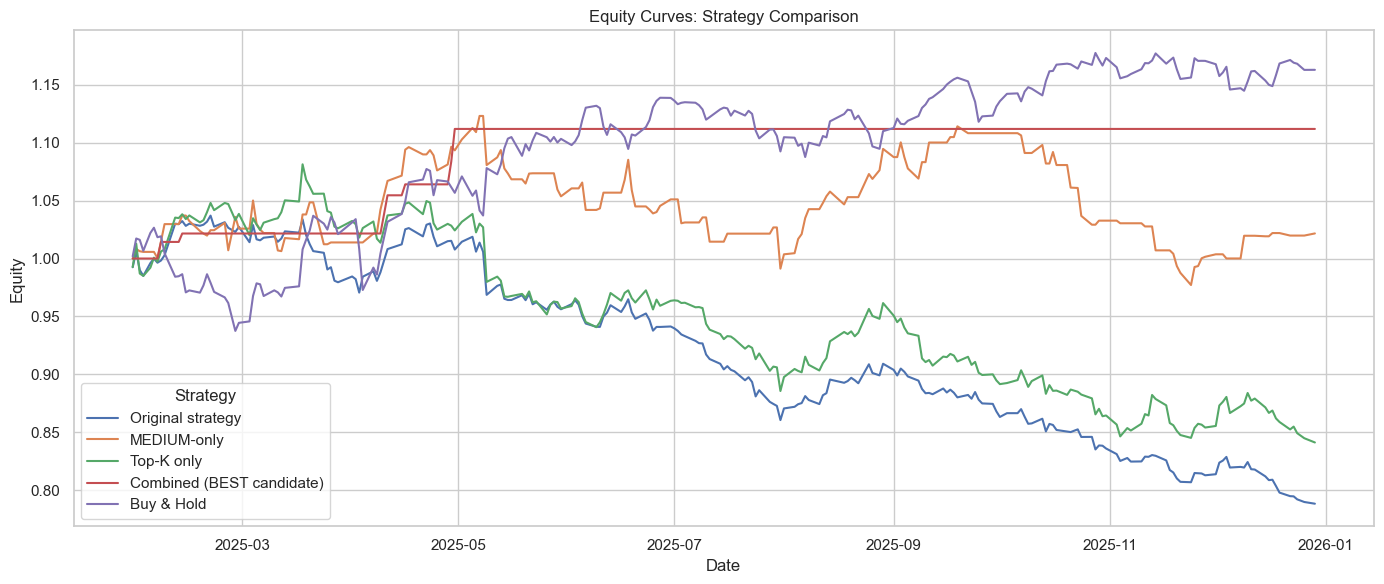

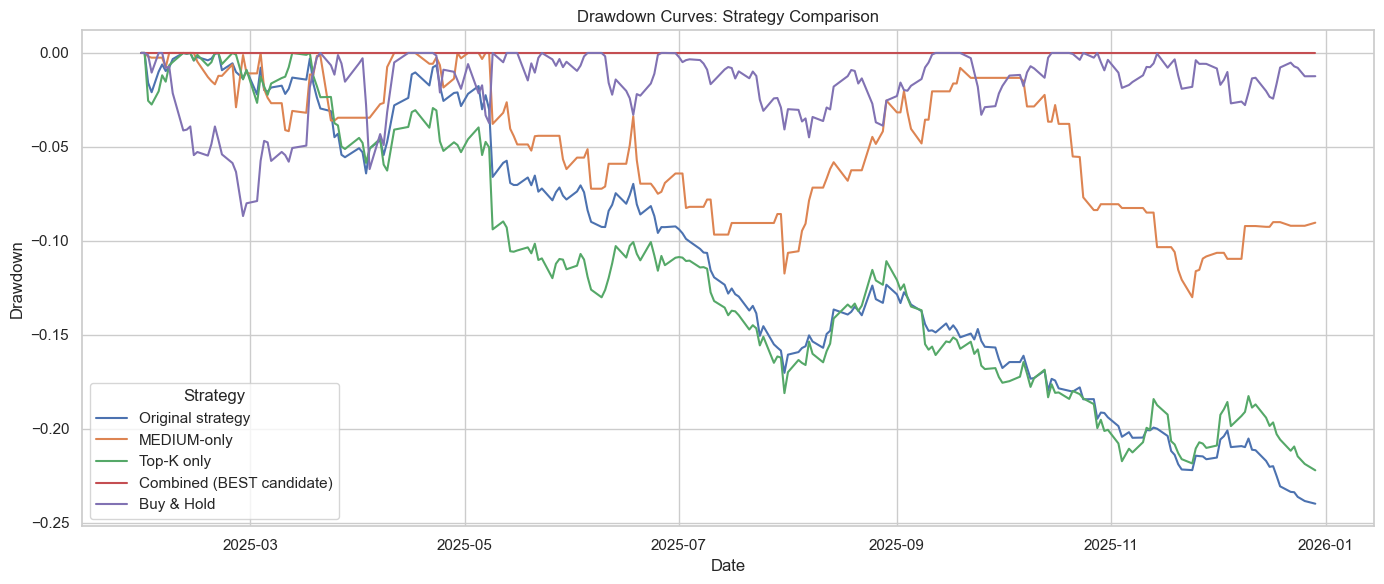

In [6]:
curve_rows = []
for name, df_s in strategy_frames.items():
    daily = df_s.groupby('Date', as_index=False)['net_return'].sum().sort_values('Date')
    daily['Strategy'] = name
    daily['Equity'] = (1.0 + daily['net_return']).cumprod()
    running_max = daily['Equity'].cummax()
    daily['Drawdown'] = (daily['Equity'] / running_max) - 1.0
    curve_rows.append(daily)

curves_df = pd.concat(curve_rows, ignore_index=True)

plt.figure(figsize=(14, 6))
sns.lineplot(data=curves_df, x='Date', y='Equity', hue='Strategy')
plt.title('Equity Curves: Strategy Comparison')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(data=curves_df, x='Date', y='Drawdown', hue='Strategy')
plt.title('Drawdown Curves: Strategy Comparison')
plt.tight_layout()
plt.show()

## STEP 9: Save Best Strategy Results

In [7]:
# Choose best model strategy (exclude Buy & Hold benchmark)
model_only = metrics_df[metrics_df['Strategy'] != 'Buy & Hold'].copy()
best_strategy_name = model_only.sort_values('Sharpe ratio', ascending=False).iloc[0]['Strategy']

best_df = strategy_frames[best_strategy_name].copy()
best_df['Strategy'] = best_strategy_name

save_cols = [
    'Ticker', 'Date', 'Regime', 'volatility_regime_label', 'Decision', 'Probability',
    'trade_mask', 'side', 'raw_size', 'weight', 'daily_return',
    'gross_return', 'txn_cost', 'net_return', 'Strategy'
]

PATHS['strategy_output'].parent.mkdir(parents=True, exist_ok=True)
best_df[save_cols].to_parquet(PATHS['strategy_output'], index=False)

logger.info('Saved best strategy result (%s) to: %s', best_strategy_name, PATHS['strategy_output'])
display(best_df[save_cols].head())

[INFO] Saved best strategy result (Combined (BEST candidate)) to: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\final_strategy_results.parquet


,Ticker,Date,Regime,volatility_regime_label,Decision,Probability,trade_mask,side,raw_size,weight,daily_return,gross_return,txn_cost,net_return,Strategy
0,ABB,2025-01-29,HIGH,HIGH,NO TRADE,0.494498,False,-1,0.0,-0.0,-0.064066,0.0,0.0,0.0,Combined (BEST candidate)
1,ABB,2025-01-30,HIGH,HIGH,NO TRADE,0.502987,False,1,0.0,0.0,0.027153,0.0,0.0,0.0,Combined (BEST candidate)
2,ABB,2025-01-31,HIGH,HIGH,NO TRADE,0.492936,False,-1,0.0,-0.0,-0.063859,0.0,0.0,0.0,Combined (BEST candidate)
3,ABB,2025-02-01,HIGH,HIGH,NO TRADE,0.506073,False,1,0.0,0.0,-0.054941,-0.0,0.0,-0.0,Combined (BEST candidate)
4,ABB,2025-02-03,HIGH,HIGH,NO TRADE,0.496291,False,-1,0.0,-0.0,0.083158,-0.0,0.0,-0.0,Combined (BEST candidate)


## Final Summary

In [8]:
best_row = model_only.sort_values('Sharpe ratio', ascending=False).iloc[0]
bh_row = metrics_df[metrics_df['Strategy'] == 'Buy & Hold'].iloc[0]

print('Strategy optimization complete.')
print(f"Best model strategy: {best_row['Strategy']}")
print(f"Best Sharpe: {best_row['Sharpe ratio']:.4f}")
print(f"Best Total return: {best_row['Total return']:.4f}")
print(f"Best Max drawdown: {best_row['Max drawdown']:.4f}")
print(f"Best Win rate: {best_row['Win rate']:.2%}")
print('---')
print(f"Buy & Hold Sharpe: {bh_row['Sharpe ratio']:.4f} | Total return: {bh_row['Total return']:.4f}")

Strategy optimization complete.
Best model strategy: Combined (BEST candidate)
Best Sharpe: 2.3265
Best Total return: 0.1119
Best Max drawdown: 0.0000
Best Win rate: 100.00%
---
Buy & Hold Sharpe: 1.2535 | Total return: 0.1629
